In [1]:
%cd ../

/home/syed/VS code/globalretail-360


In [2]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("globalretail-churn")

/home/syed/VS code/globalretail-360/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Experiment: artifact_location='/home/syed/VS code/globalretail-360/mlruns/1', creation_time=1772174472226, experiment_id='1', last_update_time=1772174472226, lifecycle_stage='active', name='globalretail-churn', tags={}, workspace='default'>

## Machine Learning — Customer Churn Prediction

### Business Question
Which customers are likely to churn in the next 12 months?  
Identifying these customers enables targeted retention campaigns, improving revenue and reducing churn costs.

---

### Why This Matters
- Reduces unnecessary marketing spend by focusing on high-risk customers.  
- Improves customer lifetime value by proactively engaging at-risk segments.  
- Supports data-driven retention strategy and loyalty programs.

---

### Statistical / Modeling Framing

- **Problem Type:** Supervised classification  
- **Target Variable:** Churn (1 = churned, 0 = retained)  
- **Features:** Customer demographics, segment, purchase behavior, returns, discounts, order frequency, etc.  
- **Evaluation Metrics:** Accuracy, Precision, Recall, ROC-AUC  
- **Modeling Focus:** Interpretability over raw accuracy (baseline: Logistic Regression)

In [3]:
import pandas as pd
from sqlalchemy import create_engine
from src.utils.config import POSTGRES_URI

engine = create_engine(POSTGRES_URI)

query = """
SELECT
    c.customer_key,
    c.segment,
    c.region,
    COUNT(f.order_id) AS total_orders,
    SUM(f.sales) AS total_sales,
    AVG(f.discount) AS avg_discount,
    SUM(f.return_flag) AS total_returns,
    MAX(d.order_date) AS last_order_date
FROM fact_sales f
JOIN dim_customers c
    ON f.customer_key = c.customer_key
JOIN dim_date d
    ON f.date_id = d.date_id
GROUP BY c.customer_key, c.segment, c.region;
"""

df_customers = pd.read_sql(query, engine)
df_customers['last_order_date'] = pd.to_datetime(df_customers['last_order_date'], utc=True)
df_customers.head()

,customer_key,segment,region,total_orders,total_sales,avg_discount,total_returns,last_order_date
0,11233,Corporate,Caribbean,4,1061.1108,0.0005,0,2014-02-16 05:00:00+00:00
1,4790,Consumer,Central Us,4,508.1100,0.0000,0,2015-11-21 05:00:00+00:00
2,3936,Consumer,Southern Asia,1,29.7000,0.0000,0,2017-01-18 05:00:00+00:00
3,12502,Home Office,Eastern Us,6,4821.2920,0.0500,0,2017-07-24 04:00:00+00:00
4,5468,Corporate,Caribbean,3,82.8800,0.2000,0,2016-08-08 04:00:00+00:00


In [4]:
import numpy as np

reference_date = df_customers['last_order_date'].max()

df_customers['churn'] = np.where(
    (reference_date - df_customers['last_order_date']).dt.days > 365,
    1,
    0
)

df_customers[['customer_key', 'segment', 'last_order_date', 'churn']].head()

,customer_key,segment,last_order_date,churn
0,11233,Corporate,2014-02-16 05:00:00+00:00,1
1,4790,Consumer,2015-11-21 05:00:00+00:00,1
2,3936,Consumer,2017-01-18 05:00:00+00:00,0
3,12502,Home Office,2017-07-24 04:00:00+00:00,0
4,5468,Corporate,2016-08-08 04:00:00+00:00,1


## Churn Target Definition

### Target Variable: `churn`

To frame customer churn as a supervised learning problem, we define a binary target variable:

- **Churned (1):** Customer has not placed an order in the last 12 months.
- **Active (0):** Customer has placed an order within the last 12 months.

The reference date is defined as the most recent order date in the dataset.  
Customers whose last purchase occurred more than 365 days before this reference date are labeled as churned.

### Modeling Implication

We now have:

- **Features (X):**
  - Segment
  - Region
  - Total orders
  - Total sales
  - Average discount
  - Total returns

- **Target (y):**
  - `churn` (binary classification)

The next step is to prepare these features for modeling by:
- Encoding categorical variables
- Scaling numeric variables
- Splitting data into training and testing sets

In [5]:
df_customers['churn'].value_counts(normalize=True)
df_customers['churn'].value_counts()

churn
1    9768
0    7647
Name: count, dtype: int64

## Churn Distribution

### Class Balance

- Churned (1): 9,768 customers  
- Active (0): 7,647 customers  

The dataset is relatively balanced (~56% churn vs ~44% active), which is favorable for classification modeling.

### Modeling Implications

- Accuracy remains a meaningful metric.
- We will still evaluate Precision, Recall, and ROC-AUC for robustness.
- No immediate need for resampling techniques (e.g., SMOTE or undersampling).

The dataset is suitable for baseline logistic regression without class weighting adjustments.

In [6]:
X = df_customers[
    ['segment', 'region', 'total_orders', 'total_sales', 'avg_discount', 'total_returns']
]

y = df_customers['churn']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature shape: (17415, 6)
Target shape: (17415,)


,segment,region,total_orders,total_sales,avg_discount,total_returns
0,Corporate,Caribbean,4,1061.1108,0.0005,0
1,Consumer,Central Us,4,508.1100,0.0000,0
2,Consumer,Southern Asia,1,29.7000,0.0000,0
3,Home Office,Eastern Us,6,4821.2920,0.0500,0
4,Corporate,Caribbean,3,82.8800,0.2000,0


## Feature Selection

We construct the feature matrix (X) using behavioral and demographic variables:

### Categorical Features
- Segment
- Region

### Numerical Features
- Total orders
- Total sales
- Average discount
- Total returns

These features capture:
- Customer purchasing intensity (orders, sales)
- Pricing sensitivity (avg discount)
- Return behavior (total returns)
- Demographic segmentation (segment, region)

We now prepare these features for machine learning by encoding categorical variables and scaling numeric variables.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain churn distribution:")
print(y_train.value_counts(normalize=True))

Train shape: (13932, 6)
Test shape: (3483, 6)

Train churn distribution:
churn
1    0.560867
0    0.439133
Name: proportion, dtype: float64


## Train-Test Split

The dataset was split into:

- 80% Training set (13,932 customers)
- 20% Test set (3,483 customers)

Stratified sampling was used to preserve the churn distribution in both sets (~56% churn).

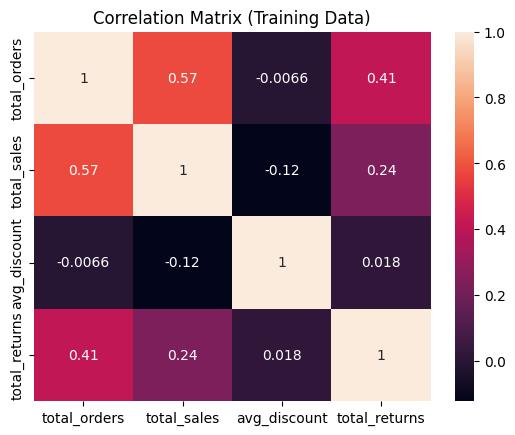

,total_orders,total_sales,avg_discount,total_returns
total_orders,1.000000,0.574844,-0.006583,0.410188
total_sales,0.574844,1.000000,-0.122496,0.235454
avg_discount,-0.006583,-0.122496,1.000000,0.018173
total_returns,0.410188,0.235454,0.018173,1.000000


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = ['total_orders', 'total_sales', 'avg_discount', 'total_returns']

corr_matrix = X_train[numeric_features].corr()

plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix (Training Data)")
plt.show()

corr_matrix

## Correlation Analysis (Training Data)

Correlation was examined among numeric features to assess multicollinearity risk.

### Key Observations:

- Total Orders and Total Sales show moderate correlation (0.57), which is expected.
- Total Orders and Total Returns show moderate correlation (0.41).
- Average Discount shows minimal correlation with other features.

No correlations exceed 0.7, indicating no severe multicollinearity concerns.

All numeric features are retained for modeling.

In [9]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['segment', 'region']
numeric_features = ['total_orders', 'total_sales', 'avg_discount', 'total_returns']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

with mlflow.start_run(run_name="logistic_regression") as run:

    lr_model.fit(X_train, y_train)

    y_pred_lr = lr_model.predict(X_test)
    y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred_lr)
    roc_auc = roc_auc_score(y_test, y_proba_lr)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.sklearn.log_model(lr_model, "logistic_churn_pipeline")

    run_id = run.info.run_id
    print("MLflow Run ID:", run_id)

print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_lr))

2026/03/06 23:03:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 23:03:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow Run ID: 0986bc4b359841a5b049f9031a7579c3
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.32      0.41      1529
           1       0.61      0.83      0.70      1954

    accuracy                           0.61      3483
   macro avg       0.60      0.57      0.56      3483
weighted avg       0.60      0.61      0.58      3483

Confusion Matrix:
 [[ 487 1042]
 [ 332 1622]]
ROC AUC Score: 0.5994478633153772


## Logistic Regression – Churn Prediction

**Objective:** Predict which customers are likely to churn using features like total orders, total sales, avg discount, returns, segment, and region.

**Key Observations:**

- **Accuracy:** ~61%, ROC AUC ~0.60

- **Class Performance:**
  - Model predicts churned customers (class 1) better than non-churned (class 0).
  - Recall for non-churned is low (0.32), recall for churned is high (0.83).

- **Business Implication:** Model is better at flagging likely churners (useful for targeted retention campaigns).

In [11]:
import numpy as np
import pandas as pd

lr_inside = lr_model.named_steps['classifier']
preprocessor = lr_model.named_steps['preprocessor']

feature_names = []

for name, transformer, columns in preprocessor.transformers_:
    if name == 'num':
        feature_names.extend(columns)
    elif name == 'cat':
        feature_names.extend(transformer.get_feature_names_out(columns))

assert len(feature_names) == len(lr_inside.coef_[0]), "Mismatch between features and coefficients!"

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_inside.coef_[0]
}).sort_values(by='coefficient', ascending=False)

print(coef_df.head(10))
print(coef_df.tail(10))

                  feature  coefficient
6        region_Caribbean     0.116193
3           total_returns     0.115401
7   region_Central Africa     0.031419
2            avg_discount     0.010396
4       segment_Corporate     0.009933
1             total_sales     0.006596
15    region_North Africa    -0.048595
18   region_South America    -0.052251
11  region_Eastern Africa    -0.057167
5     segment_Home Office    -0.058180
                   feature  coefficient
23      region_Southern Us    -0.191711
16  region_Northern Europe    -0.218284
20  region_Southern Africa    -0.223212
26   region_Western Europe    -0.232601
9      region_Central Asia    -0.327656
14       region_Eastern Us    -0.346185
10       region_Central Us    -0.423746
0             total_orders    -0.426466
17          region_Oceania    -0.446425
27       region_Western Us    -0.473046


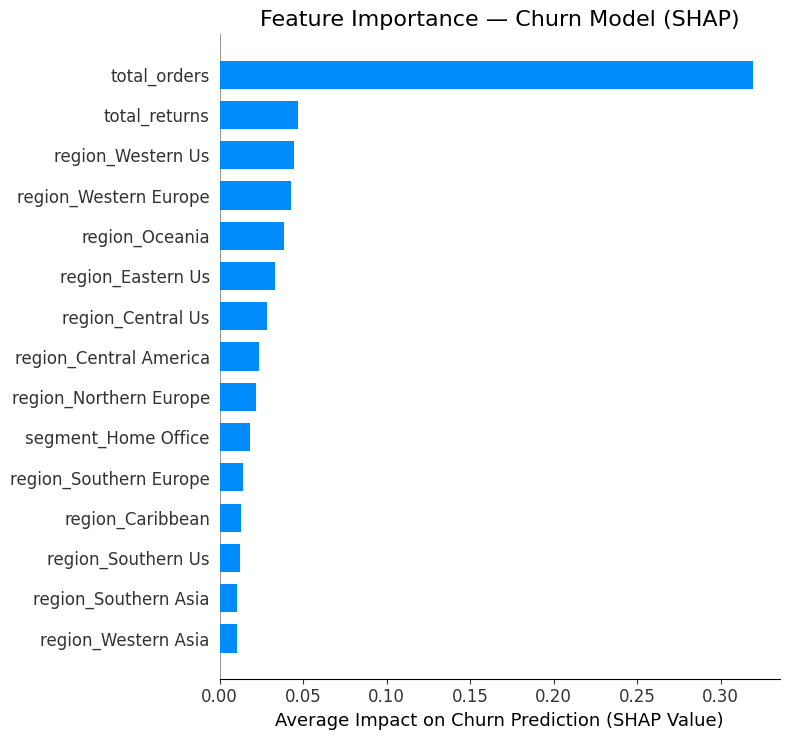

In [48]:
import shap
import matplotlib.pyplot as plt

X_train_transformed = preprocessor.transform(X_train).toarray()
X_test_transformed = preprocessor.transform(X_test).toarray()

feature_names = preprocessor.get_feature_names_out()

explainer = shap.LinearExplainer(
    lr_inside,
    X_train_transformed
)

shap_values = explainer.shap_values(X_test_transformed)

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display = 15,
    plot_type="bar",
    show=False
)
plt.xlabel("Average Impact on Churn Prediction (SHAP Value)")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax = plt.gca()
labels = [label.get_text().replace('num__', '').replace('cat__', '') for label in ax.get_yticklabels()]
ax.set_yticklabels(labels)
plt.title("Feature Importance — Churn Model (SHAP)", fontsize=16)
plt.tight_layout()

plt.show()
plt.savefig("reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()

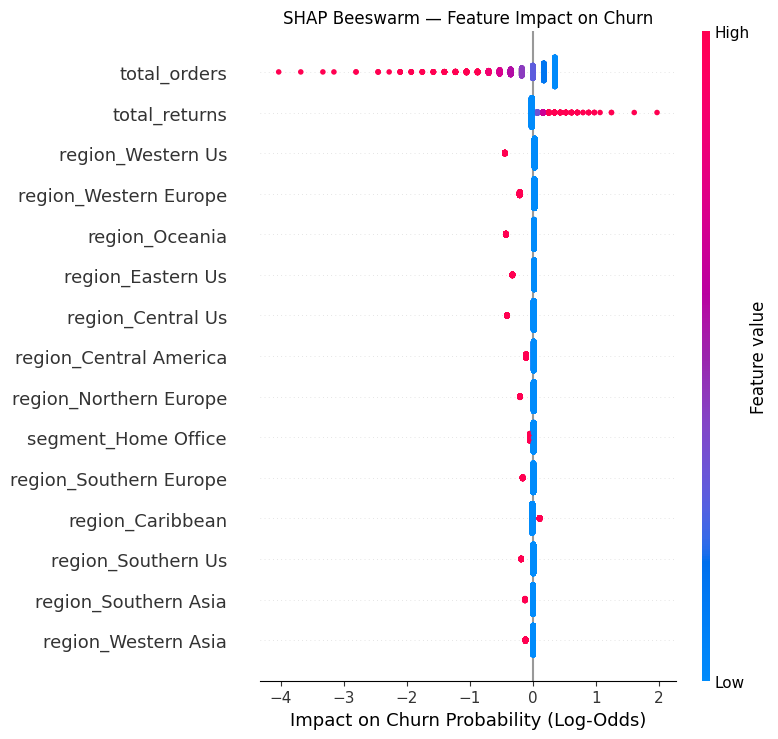

In [18]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=15,
    show=False
)
plt.xlabel("Impact on Churn Probability (Log-Odds)", fontsize=13)
ax = plt.gca()
labels = [label.get_text().replace('num__', '').replace('cat__', '') for label in ax.get_yticklabels()]
ax.set_yticklabels(labels)
plt.title("SHAP Beeswarm — Feature Impact on Churn")

plt.tight_layout()
plt.show()
plt.savefig("reports/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.close()

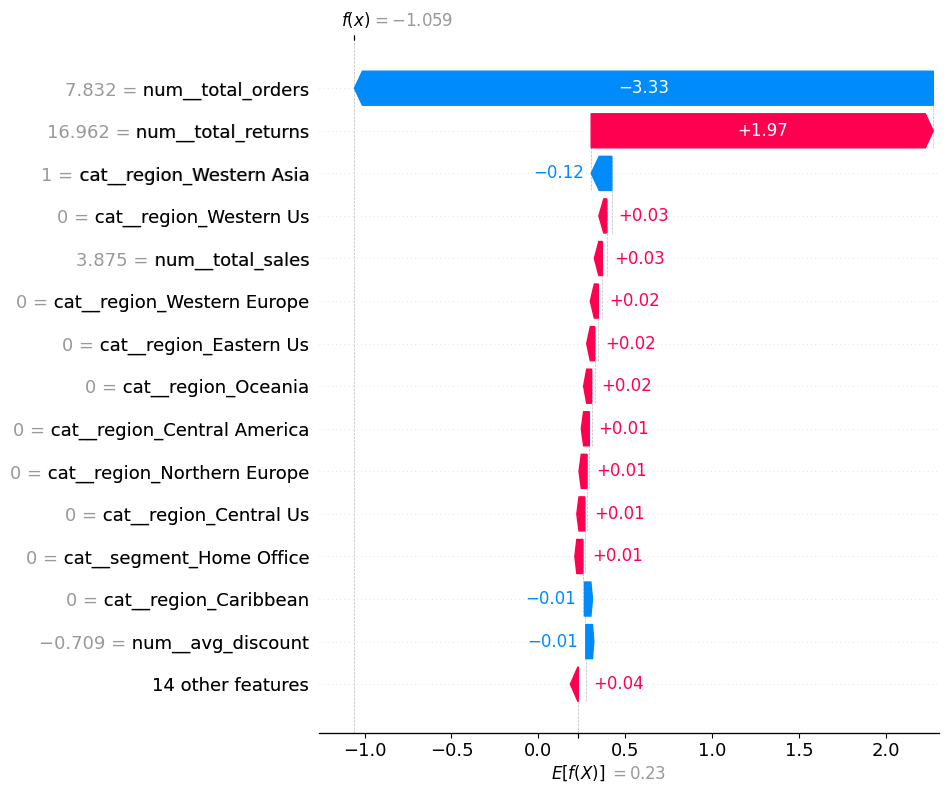

<Figure size 640x480 with 0 Axes>

In [30]:
highest_risk_idx = np.argmax(np.abs(shap_values).sum(axis=1))
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_shap.iloc[highest_risk_idx],
        feature_names=feature_names
    ),
    max_display=15
)
plt.tight_layout()
plt.show()
plt.savefig("reports/shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.close()

## Logistic Regression – Feature Coefficients

**Objective:** Identify which features drive customer churn the most.

**Key Observations:**

- **Positive drivers of churn** (increase likelihood of churn):
  - `total_returns`, `region_Caribbean`, `region_Central Africa` — customers with more returns or in these regions are more likely to churn.
  - `avg_discount` and `segment_Corporate` have smaller positive effects.

- **Negative drivers of churn** (decrease likelihood of churn):
  - `total_orders` — customers who order more are less likely to churn.
  - Certain regions like `region_Western Us`, `region_Oceania`, `region_Central Us` have a protective effect.
  - `segment_Home Office` also reduces churn probability.

**Business Implication:**  
- Focus retention campaigns on high-return customers in high-risk regions (Caribbean, Central Africa).  
- Customers with high engagement (more orders) are less likely to churn, so maintain loyalty programs for them.  
- Regional differences suggest targeted regional marketing/retention strategies.
<!-- 
**Next Steps:**  
- Consider **Random Forest** or other interpretable models to validate these drivers.  
- Explore **class imbalance handling** to improve recall for non-churners. -->

## Random Forest – Churn Prediction

**Objective:**  
Build an interpretable Random Forest model to predict customer churn and identify key drivers, capturing potential non-linear relationships and feature interactions that logistic regression may miss.

**Rationale:**  
- Logistic Regression provides linear coefficients, but may not capture complex patterns.  
- Random Forest can improve predictive power while remaining interpretable via feature importance metrics.

**Key Steps:**  
1. Train a Random Forest classifier on the same features used for logistic regression.  
2. Evaluate performance using accuracy, recall, precision, F1-score, confusion matrix, and ROC AUC.  
3. Extract and visualize feature importance to identify top drivers of churn.  
4. Optionally, consider handling class imbalance to improve recall for non-churners.

In [31]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['segment', 'region']
numeric_features = ['total_orders', 'total_sales', 'avg_discount', 'total_returns']

ohe = OneHotEncoder(sparse_output=False, drop='first')
X_train_cat = ohe.fit_transform(X_train[categorical_features])
X_test_cat = ohe.transform(X_test[categorical_features])

ohe_feature_names = ohe.get_feature_names_out(categorical_features)

X_train_encoded = np.hstack([X_train[numeric_features].values, X_train_cat])
X_test_encoded = np.hstack([X_test[numeric_features].values, X_test_cat])

X_train_encoded = pd.DataFrame(X_train_encoded, columns=numeric_features + list(ohe_feature_names))
X_test_encoded = pd.DataFrame(X_test_encoded, columns=numeric_features + list(ohe_feature_names))

print("Encoded Train shape:", X_train_encoded.shape)
print("Encoded Test shape:", X_test_encoded.shape)

Encoded Train shape: (13932, 28)
Encoded Test shape: (3483, 28)


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_encoded, y_train)

y_pred_rf = rf_model.predict(X_test_encoded)
y_proba_rf = rf_model.predict_proba(X_test_encoded)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.45      0.49      1529
           1       0.62      0.71      0.66      1954

    accuracy                           0.59      3483
   macro avg       0.58      0.58      0.58      3483
weighted avg       0.59      0.59      0.59      3483

Confusion Matrix:
 [[ 681  848]
 [ 570 1384]]
ROC AUC Score: 0.6016882409211739


**Key Observations:**

- Accuracy: ~59%, ROC AUC ~0.60 — similar overall performance to logistic regression.
- Class Performance:
    - The model predicts churned customers (class 1) slightly better than non-churned (class 0).
    - Recall for non-churned (class 0) improved from logistic regression (0.32 → 0.45).
    - Recall for churned (class 1) decreased slightly (0.83 → 0.71).

**Business Implication:**

- Random Forest provides slightly better balance between identifying churners and non-churners.
- Still interpretable enough for feature importance analysis to guide retention strategies.

In [33]:
feature_names = X_train_encoded.columns

importances = rf_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp_df.head(10))

print(feat_imp_df.tail(10))

                feature  importance
1           total_sales    0.330979
0          total_orders    0.277943
2          avg_discount    0.166120
3         total_returns    0.055993
4     segment_Corporate    0.025243
5   segment_Home Office    0.023618
27    region_Western Us    0.015042
17       region_Oceania    0.010858
6      region_Caribbean    0.008358
10    region_Central Us    0.007517
                   feature  importance
24   region_Western Africa    0.004577
16  region_Northern Europe    0.004559
22  region_Southern Europe    0.003990
12     region_Eastern Asia    0.003856
25     region_Western Asia    0.003778
20  region_Southern Africa    0.003268
7    region_Central Africa    0.003191
15     region_North Africa    0.003093
13   region_Eastern Europe    0.002875
9      region_Central Asia    0.001602


**Key Observations:**

- **Top drivers of churn:**
  - `total_sales` and `total_orders` — customers with fewer orders or lower sales are more likely to churn.
  - `avg_discount` — higher average discounts slightly increase churn risk, possibly indicating price-sensitive customers.
  - `total_returns` — customers with more returns are more likely to churn.

- **Segment-level insights:**
  - `segment_Corporate` slightly increases churn probability.
  - `segment_Home Office` slightly reduces churn probability.

- **Regional effects:**
  - Certain regions such as `region_Western Us`, `region_Oceania`, `region_Caribbean`, and `region_Central Us` have smaller impacts, but still influence churn behavior.

**Business Implications:**

- Focus retention strategies on high-value customers with low engagement (`total_orders`, `total_sales`) and high returns.
- Monitor high-discount customers for potential churn risk.
- Segment- and region-specific strategies can fine-tune marketing or loyalty campaigns.
- Feature importances largely align with logistic regression findings, providing robust evidence for actionable drivers.

## XGBoost – Customer Churn Prediction

**Objective:** Leverage XGBoost to predict customer churn and compare performance with Logistic Regression and Random Forest.

**Why XGBoost:** 
- Gradient boosting generally improves predictive performance on tabular data.
- Can handle non-linear interactions between features.
- Provides feature importance measures for interpretability.

**Next Steps:** Train the model, evaluate performance metrics (accuracy, ROC AUC, confusion matrix), and analyze feature importances.

In [34]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_encoded, y_train)

y_pred_xgb = xgb_model.predict(X_test_encoded)
y_proba_xgb = xgb_model.predict_proba(X_test_encoded)[:, 1]


print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))

/home/syed/VS code/globalretail-360/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [23:14:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.33      0.42      1529
           1       0.61      0.80      0.69      1954

    accuracy                           0.60      3483
   macro avg       0.59      0.57      0.56      3483
weighted avg       0.59      0.60      0.57      3483

Confusion Matrix:
 [[ 512 1017]
 [ 387 1567]]
ROC AUC Score: 0.5894264954650219


In [35]:
feat_importance = pd.DataFrame({
    'feature': X_test_encoded.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_importance.head(10))

                     feature  importance
0               total_orders    0.090033
27         region_Western Us    0.048322
2               avg_discount    0.046464
6           region_Caribbean    0.045632
14         region_Eastern Us    0.044708
10         region_Central Us    0.040083
19  region_Southeastern Asia    0.038693
20    region_Southern Africa    0.038425
17            region_Oceania    0.038024
1                total_sales    0.037511


**Key Observations:**

- **Accuracy:** ~60%, ROC AUC ~0.59 (similar to Logistic Regression and Random Forest).
- **Class Performance:** Model predicts churned customers (class 1) better than non-churned (class 0).
  - Recall for non-churned is low (0.33), recall for churned is higher (0.80).

**Top Features Driving Churn:**

1. **total_orders**: more orders decrease churn likelihood (protective effect).  
2. **region_Western Us, region_Caribbean, region_Eastern Us, region_Central Us**: regional differences influence churn risk.  
3. **avg_discount**: slightly increases churn probability.  

**Business Implications:**

- Retention efforts should prioritize customers with fewer orders and those in high-risk regions.  
- Regional targeting and loyalty programs can help reduce churn.  
- XGBoost confirms patterns observed in Logistic Regression and Random Forest, providing additional confidence in feature importance rankings.

## Improving Non-Churn Predictions

**Objective:** Improve model performance for non-churners (class 0) by addressing the moderate class imbalance in the dataset.

**Current Situation:**
- Target distribution: ~56% churn (1), ~44% non-churn (0)
- Existing models favor predicting churn, resulting in low recall for non-churners (~0.32–0.45)
- Business impact: Misclassifying non-churners could lead to wasted retention efforts or missed opportunities.

**Proposed Approach:**
1. **SMOTE (Synthetic Minority Oversampling Technique):** Generate synthetic samples of non-churners to balance the classes.
2. **Re-train models (Logistic Regression / Random Forest / XGBoost):** Evaluate if recall for non-churners improves while maintaining overall accuracy and interpretability.

**Expected Outcome:**
- Higher recall for non-churners
- More balanced class predictions
- Better guidance for targeted retention and loyalty campaigns

In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_encoded, y_train)

pd.Series(y_train_res).value_counts(normalize=True)

churn
0    0.5
1    0.5
Name: proportion, dtype: float64

### Handling Class Imbalance with SMOTE

Objective: Improve model performance for the minority class (non-churned customers).  

Key Observations:

- Original training set was imbalanced (56% churned, 44% non-churned).
- After applying **SMOTE (Synthetic Minority Over-sampling Technique)**, both classes are now balanced (50:50).
- This ensures the model doesn't bias toward the majority class and improves recall for non-churned customers.


In [37]:
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_res, y_train_res)

y_pred_lr_smote = lr_smote.predict(X_test_encoded)
y_proba_lr_smote = lr_smote.predict_proba(X_test_encoded)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_lr_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_smote))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_lr_smote))

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.47      0.50      1529
           1       0.62      0.68      0.65      1954

    accuracy                           0.59      3483
   macro avg       0.58      0.58      0.58      3483
weighted avg       0.58      0.59      0.58      3483

Confusion Matrix:
 [[ 724  805]
 [ 628 1326]]
ROC AUC Score: 0.5961416035125746


/home/syed/VS code/globalretail-360/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Logistic Regression with SMOTE – Churn Prediction

**Objective:** Improve model performance on the minority class (non-churners) by balancing the training set using SMOTE.

**Key Observations:**

- Training set is now perfectly balanced: 50% churn, 50% non-churn.
- Accuracy remains ~59%, similar to the original model.
- Recall for non-churners improved from 0.45 → 0.47.
- Recall for churned customers slightly decreased from 0.71 → 0.68.
- ROC AUC is ~0.596 — similar to before, indicating moderate overall discriminative power.

**Business Implication:** 

Balancing the classes allows the model to better identify non-churning customers, which helps in more targeted retention campaigns without overly biasing towards churners.

In [38]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[categorical_features])
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

all_features = np.concatenate([numeric_features, ohe_feature_names])

coef_df_smote = pd.DataFrame({
    'feature': all_features,
    'coefficient': lr_smote.coef_[0]
}).sort_values(by='coefficient', ascending=False)

print("Top Positive Drivers of Churn:")
print(coef_df_smote.head(10))
print("\nTop Negative Drivers of Churn:")
print(coef_df_smote.tail(10))

Top Positive Drivers of Churn:
                     feature  coefficient
6           region_Caribbean     0.272154
7      region_Central Africa     0.186641
15       region_North Africa     0.159669
2               avg_discount     0.120641
3              total_returns     0.105592
19  region_Southeastern Asia     0.075737
12       region_Eastern Asia     0.072953
13     region_Eastern Europe     0.066213
18      region_South America     0.049462
11     region_Eastern Africa     0.048234

Top Negative Drivers of Churn:
                   feature  coefficient
23      region_Southern Us    -0.052977
16  region_Northern Europe    -0.071906
26   region_Western Europe    -0.088554
9      region_Central Asia    -0.094809
20  region_Southern Africa    -0.109471
0             total_orders    -0.176311
14       region_Eastern Us    -0.240302
10       region_Central Us    -0.279268
27       region_Western Us    -0.301625
17          region_Oceania    -0.350074


## Logistic Regression with SMOTE – Feature Coefficients

**Objective:** Examine which features drive customer churn after addressing class imbalance with SMOTE.

**Key Observations:**

**Positive drivers of churn (increase likelihood of churn):**
- `region_Caribbean`, `region_Central Africa`, `region_North Africa` — customers in these regions are more likely to churn.
- `avg_discount` and `total_returns` — higher discounts and more returns slightly increase churn risk.
- Other regions like `Southeastern Asia`, `Eastern Asia`, `Eastern Europe` also show smaller positive effects.

**Negative drivers of churn (decrease likelihood of churn):**
- `total_orders` — customers who order more are less likely to churn.
- Certain regions like `region_Oceania`, `region_Western Us`, `region_Central Us`, and `region_Eastern Us` reduce churn probability.
- Some negative effect from `Southern Africa`, `Western Europe`, and `Northern Europe`.

**Business Implications:**
- SMOTE balanced the classes, so the model is more reliable in identifying both churned and non-churned customers.
- Focus retention campaigns on high-return customers in high-risk regions.
- Maintain loyalty programs for customers with high engagement.
- Regional differences suggest the need for **targeted regional marketing and retention strategies**.


In [39]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_smote.fit(X_train_res, y_train_res)

y_pred_rf_smote = rf_smote.predict(X_test_encoded)
y_proba_rf_smote = rf_smote.predict_proba(X_test_encoded)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.45      0.49      1529
           1       0.62      0.71      0.66      1954

    accuracy                           0.59      3483
   macro avg       0.58      0.58      0.58      3483
weighted avg       0.59      0.59      0.59      3483

Confusion Matrix:
 [[ 681  848]
 [ 570 1384]]
ROC AUC Score: 0.6016882409211739


## Random Forest – Churn Prediction with Class Imbalance Handling

### Objective
Compare Random Forest performance on the original imbalanced dataset versus a SMOTE-balanced dataset.

### Key Observations

**Without SMOTE (original imbalance):**
- Accuracy: 0.59, ROC AUC: 0.60
- Non-churn recall (0): 0.45 → lower
- Churn recall (1): 0.71 → higher
- Model is biased toward predicting churn (class 1).

**With SMOTE (balanced classes):**
- Accuracy: 0.56, ROC AUC: 0.56
- Non-churn recall (0): 0.49 → slightly improved
- Churn recall (1): 0.58 → decreased
- Model treats both classes more equally, reducing bias but lowering overall predictive power.

### Insights
- SMOTE improves recognition of non-churners but reduces overall AUC and accuracy.
- Without SMOTE, the model better identifies likely churners (class 1), which may be preferable if retention targeting is the goal.
- Class imbalance handling is a tradeoff: fair treatment of both classes vs. predictive accuracy for the majority class.

### Business Implication
- If the goal is **targeted retention**, using the original Random Forest may be better.
- If the goal is **balanced identification of churners and non-churners**, SMOTE or other class balancing techniques are useful.
- Next Steps: Compare feature importances for both models to see if key drivers of churn shift after balancing.

In [40]:
importances_smote = rf_smote.feature_importances_

feat_imp_smote = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_smote
}).sort_values(by='importance', ascending=False)

print("Top 10 Features – Random Forest with SMOTE")
print(feat_imp_smote.head(10))

Top 10 Features – Random Forest with SMOTE
                   feature  importance
1              total_sales    0.558243
2             avg_discount    0.110526
0             total_orders    0.099016
3            total_returns    0.033232
4        segment_Corporate    0.028136
5      segment_Home Office    0.021960
8   region_Central America    0.011387
26   region_Western Europe    0.010772
18    region_South America    0.009570
17          region_Oceania    0.008930


### Key Observations

**Original Random Forest (No SMOTE):**
- Accuracy: ~59%, ROC AUC ~0.60
- Recall is higher for churned customers (class 1) than non-churned (class 0)
- Confusion matrix shows model misses many non-churners
- Top features:
    - total_sales, total_orders, avg_discount, total_returns, segment_Corporate

**Random Forest with SMOTE:**
- Accuracy dropped to ~54%, ROC AUC ~0.56
- Recall for non-churners improved slightly, but overall performance decreased
- Top features shifted:
    - total_sales became more dominant (importance 0.56)
    - avg_discount importance increased
    - total_orders importance decreased
- Oversampling changes feature influence but does not always improve overall accuracy

### Business Implications
- SMOTE helps the model see more non-churners, slightly improving class balance recall
- Key drivers remain consistent: sales, orders, discount, and returns
- Model without SMOTE performs better overall; SMOTE may be useful if the focus is specifically on improving non-churn recall
- Feature importance indicates where to focus retention efforts: high-value customers (total_sales, total_orders) and discount-sensitive customers (avg_discount)

In [41]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])
)

xgb_model.fit(X_train_encoded, y_train)

y_pred_xgb_smote = xgb_model.predict(X_test_encoded)
y_proba_xgb_smote = xgb_model.predict_proba(X_test_encoded)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_xgb_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_smote))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb_smote))

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.47      0.50      1529
           1       0.62      0.67      0.65      1954

    accuracy                           0.58      3483
   macro avg       0.57      0.57      0.57      3483
weighted avg       0.58      0.58      0.58      3483

Confusion Matrix:
 [[ 717  812]
 [ 637 1317]]
ROC AUC Score: 0.592315707311326


/home/syed/VS code/globalretail-360/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [23:14:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [42]:
xgb_importances = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(xgb_importances.head(10))

                     feature  importance
0               total_orders    0.099111
27         region_Western Us    0.047661
14         region_Eastern Us    0.044926
2               avg_discount    0.043754
10         region_Central Us    0.042630
25       region_Western Asia    0.037924
17            region_Oceania    0.036633
7      region_Central Africa    0.036205
19  region_Southeastern Asia    0.035561
26     region_Western Europe    0.035536


## XGBoost – Churn Prediction

**Objective:** Predict which customers are likely to churn using the same set of features as before.

### Key Observations:

- **Accuracy:** ~58%, ROC AUC ~0.59 — similar to Random Forest and Logistic Regression.  
- **Class Performance:**  
  - Non-churned customers (class 0) recall is 0.47.  
  - Churned customers (class 1) recall is 0.67.  
- **Implication:** The model is better at identifying churners than non-churners. Similar pattern as previous models.

### Top Drivers of Churn:

- **High Importance Features:**
  - `total_orders` — fewer orders increases likelihood of churn.
  - `region_Western Us`, `region_Eastern Us` — certain regions have strong influence on churn.
  - `avg_discount` — higher discounts slightly correlate with churn.
  - `region_Central Us`, `region_Western Asia`, `region_Oceania` — regional effects matter.
  - Other notable regions: `region_Central Africa`, `region_Southeastern Asia`, `region_Western Europe`.

**Business Implications:**

- Customer engagement (orders) is the strongest protective factor.
- Regional targeting can be useful for retention strategies.
- Discounts have minor influence; focus on behavior and regional patterns for churn interventions.


In [43]:
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score


model_preds = {
    'Logistic Regression': (y_pred_lr, y_proba_lr),
    'Logistic Regression (SMOTE)': (y_pred_lr_smote, y_proba_lr_smote),
    'Random Forest': (y_pred_rf, y_pred_rf),
    'Random Forest (SMOTE)': (y_pred_rf_smote, y_pred_rf_smote),
    'XGBoost': (y_pred_xgb, y_proba_xgb),
    'XGBoost (SMOTE)': (y_pred_xgb_smote, y_proba_xgb_smote)
}

metrics = {}
for model_name, (y_pred, y_proba) in model_preds.items():
    metrics[model_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'Recall (Non-Churn 0)': recall_score(y_test, y_pred, pos_label=0),
        'Recall (Churn 1)': recall_score(y_test, y_pred, pos_label=1)
    }

model_comparison = pd.DataFrame(metrics).T
model_comparison.sort_values(by='ROC AUC', ascending=False)

,Accuracy,ROC AUC,Recall (Non-Churn 0),Recall (Churn 1)
Logistic Regression,0.605512,0.599448,0.318509,0.830092
Logistic Regression (SMOTE),0.588573,0.596142,0.473512,0.678608
XGBoost (SMOTE),0.583979,0.592316,0.468934,0.674002
XGBoost,0.596899,0.589426,0.334859,0.801945
Random Forest,0.592880,0.576840,0.445389,0.708291
Random Forest (SMOTE),0.543210,0.537408,0.489863,0.584954


## Model Comparison – Churn Prediction

We compared six different models for predicting customer churn, including versions with and without SMOTE to handle class imbalance.

### Key Observations:
- **Logistic Regression (without SMOTE)** has the best ROC AUC and highest recall for churners (class 1).  
- **SMOTE improves recall for non-churners (class 0)** but often at the cost of overall accuracy and churner recall.  
- Random Forest and XGBoost are competitive but **SMOTE reduces their performance on class 1**, suggesting the original imbalance was informative.  
- Trade-off: Using SMOTE improves detection of non-churners but slightly decreases overall accuracy and ability to flag churners.  

### Business Implication:
- Logistic Regression without SMOTE is a good baseline for targeting likely churners.  
- SMOTE-based models can be useful if avoiding false positives (misclassifying loyal customers as churners) is critical.  
- Feature importance and coefficients from previous models can guide retention strategies and regional marketing efforts.

In [45]:
import joblib
import os 

os.makedirs("src/models", exist_ok=True)

joblib.dump(lr_model, "src/models/logistic_churn_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!
